In [1]:
import seaborn as sns
import pandas as pd
# Wczytanie zbioru Titanic
df = sns . load_dataset ('titanic')
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [2]:
print("Overall survival rate:")
print(df['survived'].value_counts()[1]/len(df))
print("Survival rate by gender")
print(df.groupby('sex')['survived'].mean())
print("Survival rate by class")
print(df.groupby('pclass')['survived'].mean())

Overall survival rate:
0.3838383838383838
Survival rate by gender
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
Survival rate by class
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


<Axes: xlabel='sex', ylabel='survived'>

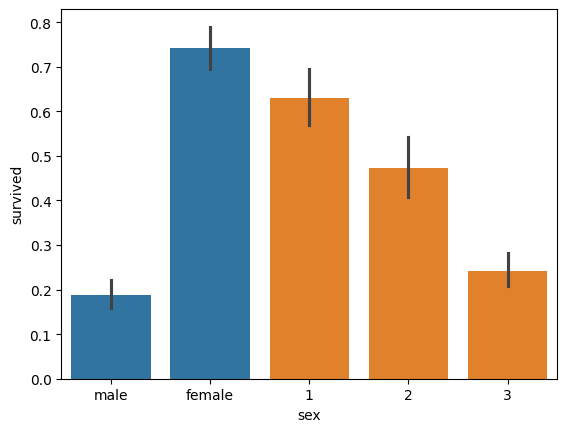

In [3]:
sns.barplot(data=df, x='sex', y='survived')
sns.barplot(data=df, x='pclass', y='survived')

In [4]:
df.drop('deck', axis=1, inplace=True)

In [5]:
df['age'] = df.age.fillna(df.age.mean())
df['sex'].replace({'male': 0, 'female': 1}, inplace=True)
df['alive'].replace({'no': 0, 'yes': 1}, inplace=True)
df['class'].replace({'First': 1, 'Second': 2, 'Third': 3}, inplace=True)
df['embark_town'].replace({'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2}, inplace=True)
df['alone'].replace({False: 0, True: 1}, inplace=True)
df['embarked'].replace({'S': 0, 'C': 1, 'Q': 2}, inplace=True)
df['who'].replace({'man': 0, 'woman': 1, 'child': 2}, inplace=True)
df['adult_male'].replace({False: 0, True: 1}, inplace=True)
df['embarked'] = df['embarked'].fillna(df["embarked"] .mode()[0])
df['embark_town'] = df['embark_town'].fillna(df["embark_town"] .mode()[0])

/tmp/ipython-input-2799023186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].replace({'male': 0, 'female': 1}, inplace=True)
/tmp/ipython-input-2799023186.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'].replace({'male': 0, 'female': 1}, inplace=True)
/tmp/ipython-input-2

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,0.0,3,0,1,0.0,0,0
1,1,1,1,38.0,1,0,71.2833,1.0,1,1,0,1.0,1,0
2,1,3,1,26.0,0,0,7.9250,0.0,3,1,0,0.0,1,1
3,1,1,1,35.0,1,0,53.1000,0.0,1,1,0,0.0,1,0
4,0,3,0,35.0,0,0,8.0500,0.0,3,0,1,0.0,0,1


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (712, 13)
Shape of X_test: (179, 13)
Shape of y_train: (712,)
Shape of y_test: (179,)


In [8]:
print("Class proportions in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass proportions in y_test:")
print(y_test.value_counts(normalize=True))

Class proportions in y_train:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Class proportions in y_test:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [9]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

log_reg_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [10]:
import pandas as pd

coefficients = pd.Series(log_reg_model.coef_[0], index=X_train.columns)

sorted_coefficients = coefficients.abs().sort_values(ascending=False)

print("Sorted Coefficients (by absolute value):\n", sorted_coefficients)

print("\nTop 3 most influential features:")
for feature in sorted_coefficients.head(3).index:
    coeff_value = coefficients[feature]
    print(f"- {feature}: Coefficient = {coeff_value:.4f}")
    if coeff_value > 0:
        print(f"  An increase in '{feature}' is associated with an increased log-odds of survival (positive impact).")
    else:
        print(f"  An increase in '{feature}' is associated with a decreased log-odds of survival (negative impact).")

Sorted Coefficients (by absolute value):
 alive          7.010016
adult_male     0.891558
class          0.372159
pclass         0.372159
sex            0.356037
sibsp          0.314747
alone          0.314148
parch          0.158632
who            0.103811
embark_town    0.069600
embarked       0.069600
age            0.026209
fare           0.000377
dtype: float64

Top 3 most influential features:
- alive: Coefficient = 7.0100
  An increase in 'alive' is associated with an increased log-odds of survival (positive impact).
- adult_male: Coefficient = -0.8916
  An increase in 'adult_male' is associated with a decreased log-odds of survival (negative impact).
- class: Coefficient = -0.3722
  An increase in 'class' is associated with a decreased log-odds of survival (negative impact).


In [11]:
import numpy as np

odds_ratios = np.exp(coefficients)

print("Odds Ratios for each variable:")
print(odds_ratios)

sex_odds_ratio = odds_ratios['sex']
print(f"\nOdds Ratio for 'sex': {sex_odds_ratio:.4f}")
print(f"\nWhat this means is that whether you survived the sinking or not highly depended on your sex.")

Odds Ratios for each variable:
pclass            0.689245
sex               1.427661
age               0.974132
sibsp             0.729974
parch             0.853311
fare              0.999623
embarked          1.072079
class             0.689245
who               1.109391
adult_male        0.410016
embark_town       1.072079
alive          1107.672381
alone             0.730411
dtype: float64

Odds Ratio for 'sex': 1.4277

What this means is that whether you survived the sinking or not highly depended on your sex.


In [14]:
log_reg_model.predict(X_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

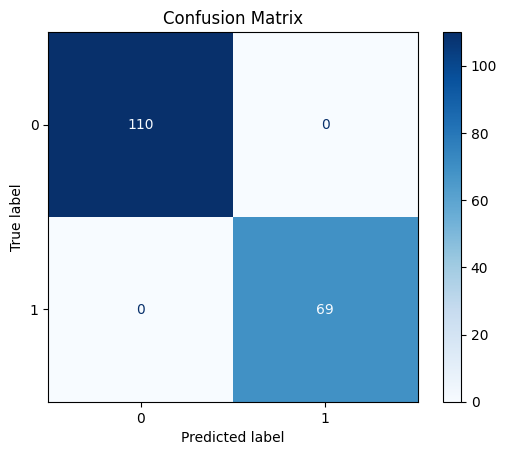

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = log_reg_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
TN = cm[0, 0]
FP = cm[0, 1]
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall (Sensitivity): 1.0000
F1-Score: 1.0000
Specificity: 1.0000


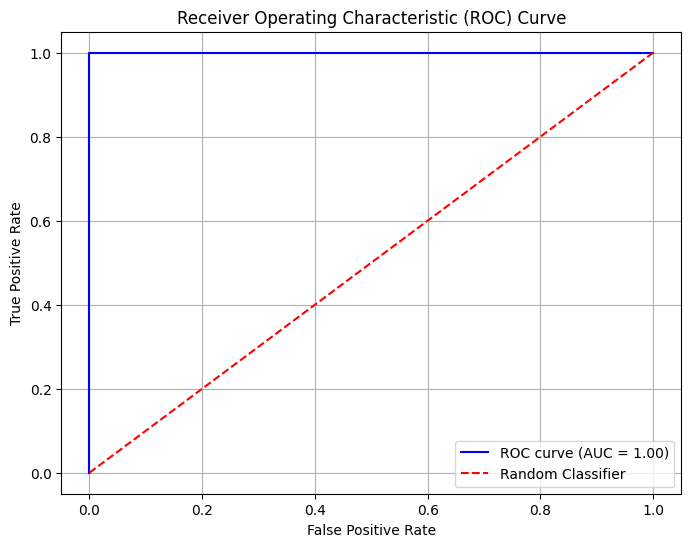

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score

y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Recall and Precision at different thresholds:\n")
for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold:.1f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}\n")

Recall and Precision at different thresholds:

Threshold: 0.3
  Precision: 1.0000
  Recall: 1.0000

Threshold: 0.4
  Precision: 1.0000
  Recall: 1.0000

Threshold: 0.5
  Precision: 1.0000
  Recall: 1.0000

Threshold: 0.6
  Precision: 1.0000
  Recall: 1.0000

Threshold: 0.7
  Precision: 1.0000
  Recall: 1.0000



In [19]:
from sklearn.linear_model import LogisticRegression

log_reg_balanced_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

log_reg_balanced_model.fit(X_train, y_train)

Balanced Logistic Regression model trained successfully.


In [20]:
y_pred_balanced = log_reg_balanced_model.predict(X_test)

Predictions made with the balanced model.


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
TN_balanced = cm_balanced[0, 0]
FP_balanced = cm_balanced[0, 1]
specificity_balanced = TN_balanced / (TN_balanced + FP_balanced) if (TN_balanced + FP_balanced) != 0 else 0

print(f"Balanced Model Metrics:")
print(f"Accuracy: {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall (Sensitivity): {recall_balanced:.4f}")
print(f"F1-Score: {f1_balanced:.4f}")
print(f"Specificity: {specificity_balanced:.4f}")

Balanced Model Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall (Sensitivity): 1.0000
F1-Score: 1.0000
Specificity: 1.0000


In [22]:
y_pred_proba_balanced = log_reg_balanced_model.predict_proba(X_test)[:, 1]

Predicted probabilities generated for the balanced model.


In [23]:
from sklearn.metrics import roc_auc_score

auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)
print(f"AUC Score for Balanced Model: {auc_balanced:.4f}")

AUC Score for Balanced Model: 1.0000


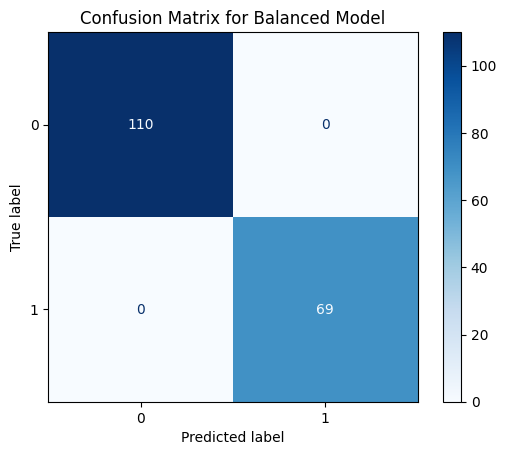

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=log_reg_balanced_model.classes_)
disp_balanced.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Balanced Model')
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

scaler.fit(X_train[numerical_cols])

X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Numerical features in X_train and X_test standardized successfully.")
print("First 5 rows of X_train after scaling:")
print(X_train.head())
print("\nFirst 5 rows of X_test after scaling:")
print(X_test.head())

Numerical features in X_train and X_test standardized successfully.
First 5 rows of X_train after scaling:
     pclass  sex       age     sibsp     parch      fare  embarked class  who  \
692       3    0 -0.006741 -0.465084 -0.466183  0.513812       0.0     3    0   
481       2    0 -0.006741 -0.465084 -0.466183 -0.662563       0.0     2    0   
527       1    0 -0.006741 -0.465084 -0.466183  3.955399       0.0     1    0   
855       3    1 -0.906260 -0.465084  0.727782 -0.467874       0.0     3    1   
801       2    1  0.093280  0.478335  0.727782 -0.115977       0.0     2    1   

     adult_male  embark_town  alive  alone  
692           1          0.0      1      1  
481           1          0.0      0      1  
527           1          0.0      0      1  
855           0          0.0      1      0  
801           0          0.0      1      0  

First 5 rows of X_test after scaling:
     pclass  sex       age     sibsp     parch      fare  embarked class  who  \
565       3    0

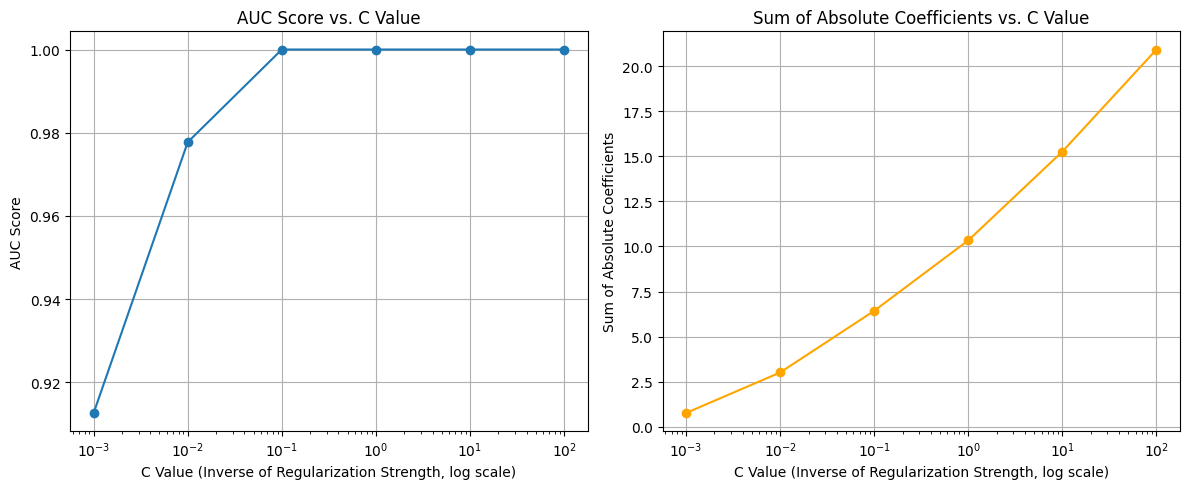

Evaluation of L2 regularization with varying C values complete, and plots displayed.


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

c_values = [0.001, 0.01, 0.1, 1, 10, 100]

auc_scores = []
abs_coef_sums = []

for c in c_values:
    model = LogisticRegression(penalty='l2', solver='liblinear', random_state=42, C=c)

    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)

    abs_coef_sum = np.sum(np.abs(model.coef_))
    abs_coef_sums.append(abs_coef_sum)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(c_values, auc_scores, marker='o')
plt.xscale('log')
plt.xlabel('C Value (Inverse of Regularization Strength, log scale)')
plt.ylabel('AUC Score')
plt.title('AUC Score vs. C Value')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(c_values, abs_coef_sums, marker='o', color='orange')
plt.xscale('log')
plt.xlabel('C Value (Inverse of Regularization Strength, log scale)')
plt.ylabel('Sum of Absolute Coefficients')
plt.title('Sum of Absolute Coefficients vs. C Value')
plt.grid(True)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

C = 0.1

log_reg_l2 = LogisticRegression(penalty='l2', solver='liblinear', random_state=42, C=C)
log_reg_l2.fit(X_train, y_train)
print(f"L2 Regularized Model (C={C}) trained successfully.")

log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=C)
log_reg_l1.fit(X_train, y_train)
print(f"L1 Regularized Model (C={C}) trained successfully.\n")

coef_l2 = pd.Series(log_reg_l2.coef_[0], index=X_train.columns)
print("Coefficients for L2 Regularized Model:")
print(coef_l2)

coef_l1 = pd.Series(log_reg_l1.coef_[0], index=X_train.columns)
print("\nCoefficients for L1 Regularized Model:")
print(coef_l1)

L2 Regularized Model (C=0.1) trained successfully.
L1 Regularized Model (C=0.1) trained successfully.

Coefficients for L2 Regularized Model:
pclass        -0.346627
sex            0.385652
age           -0.160227
sibsp         -0.238363
parch         -0.095647
fare           0.049528
embarked       0.078237
class         -0.346627
who            0.322109
adult_male    -0.657591
embark_town    0.078237
alive          3.462890
alone         -0.214147
dtype: float64

Coefficients for L1 Regularized Model:
pclass        -0.755558
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.000000
class         -0.301562
who            0.000000
adult_male    -0.891024
embark_town    0.000000
alive          6.009528
alone          0.000000
dtype: float64
